# Spatial protocluster generation

Extends `protoclusterGen.ipynb` by giving the sampled protostars positions. The positions follow a 3D log-normal fractional Brownian motion (fBm) density field with fractal dimension $D = 2.4$.

In [1]:
from ocotillopmf import PowerLawAccrete, PMF
from ocotillopmf.spatial import Spatial
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmasher as cmr

In [2]:
#Cluster parameters
Nstar = 1000   #number of protostars
D = 2.4        #fractal dimension of the fBm
ndim = 3       #Euclidean dimension
L = 10.0       #box size (pc); positions lie in [-L/2, L/2]
sigma = 1.5    #standard deviation of ln(density)

In [3]:
#Draw the cluster from the log-fBm PDF; the same seed regenerates that (recentred) field for plotting
spatialObj = Spatial(seed=11235813)
x, y, z = spatialObj.makeStellarCluster(nstar=Nstar, ndim=ndim, D=D, L=L, sigma=sigma, recenter=True)

grid, spatProb = spatialObj.makeFBM(ndim=ndim, D=D, L=L, scale=sigma)
spatProb = spatialObj.recenterField(spatProb)

In [4]:
#Protostar masses from the PMF, with the accretion model of protoclusterGen.ipynb
plawObj = PowerLawAccrete(0.5, 0.75, 3.6E-5, deltan1 = 1.0)
pmfObj = PMF(plawObj)
m_arr, mf_arr = pmfObj.PhiInvertSample(N=Nstar)

In [5]:
#Shared plot style: colour and marker size scale with log mass

vmin, vmax = -1.0, np.log10(8.0)
massCmap = cmr.get_sub_cmap(cmr.wildfire, start = 0.1, stop = 0.9)
logm = np.log10(m_arr)
starSize = 5 + 75 * np.clip((logm - vmin) / (vmax - vmin), 0, 1)**1.5
drawOrder = np.argsort(m_arr)  #massive stars drawn on top

def plotStars(ax, a, b, **kwargs):
    return ax.scatter(a[drawOrder], b[drawOrder], c=logm[drawOrder], 
                      s=starSize[drawOrder], cmap=massCmap, 
                      vmin=vmin, vmax=vmax, linewidths=0, **kwargs)

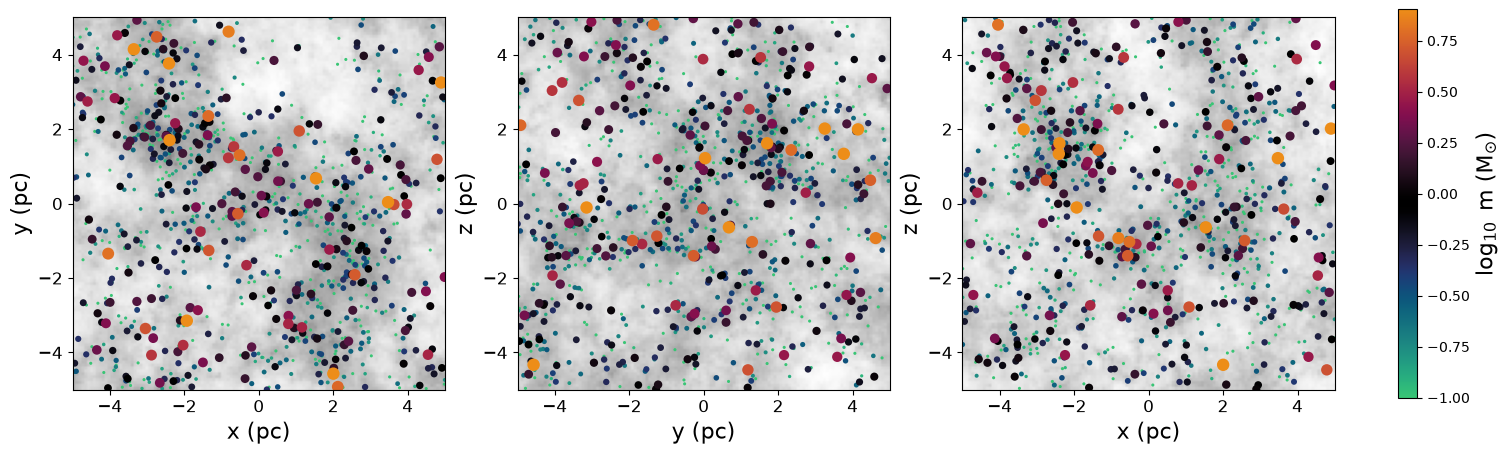

In [6]:
#Cluster projections over the projected fBm PDF
planes = [(x, y, "x", "y", 2), (y, z, "y", "z", 0), (x, z, "x", "z", 1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, (a, b, la, lb, si) in zip(axes, planes):
    sc = plotStars(ax, a, b)

    pdfProj = np.sum(spatProb, axis=si)
    ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.5, origin='lower', norm=colors.LogNorm())
    
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_aspect('equal')
    ax.set_xlabel(f"{la} (pc)", fontsize=16)
    ax.set_ylabel(f"{lb} (pc)", fontsize=16)
    ax.tick_params(which='both', axis='both', labelsize=12)
cb = fig.colorbar(sc, ax=axes, shrink=0.8)
cb.set_label(r"$\log_{10}$ m (M$_{\odot}$)", fontsize=16)
plt.show()

## Mass segregation

Impose primordial mass segregation with the Baumgardt et al. (2008) scheme used in McLuster. Positions are ranked from most to least bound, and stars are swapped in from heaviest to lightest. $S = 0$ gives no segregation, and $S \to 1$ puts the most massive stars in the most bound positions.

In [7]:
#Same seed, so the same field and positions; only which star sits where changes
S = 0.75
spatialObj = Spatial(seed=11235813)
xs, ys, zs = spatialObj.makeStellarCluster(nstar=Nstar, ndim=ndim, D=D, L=L, sigma=sigma,massSegregate=True, S=S, masses=m_arr, recenter=True)

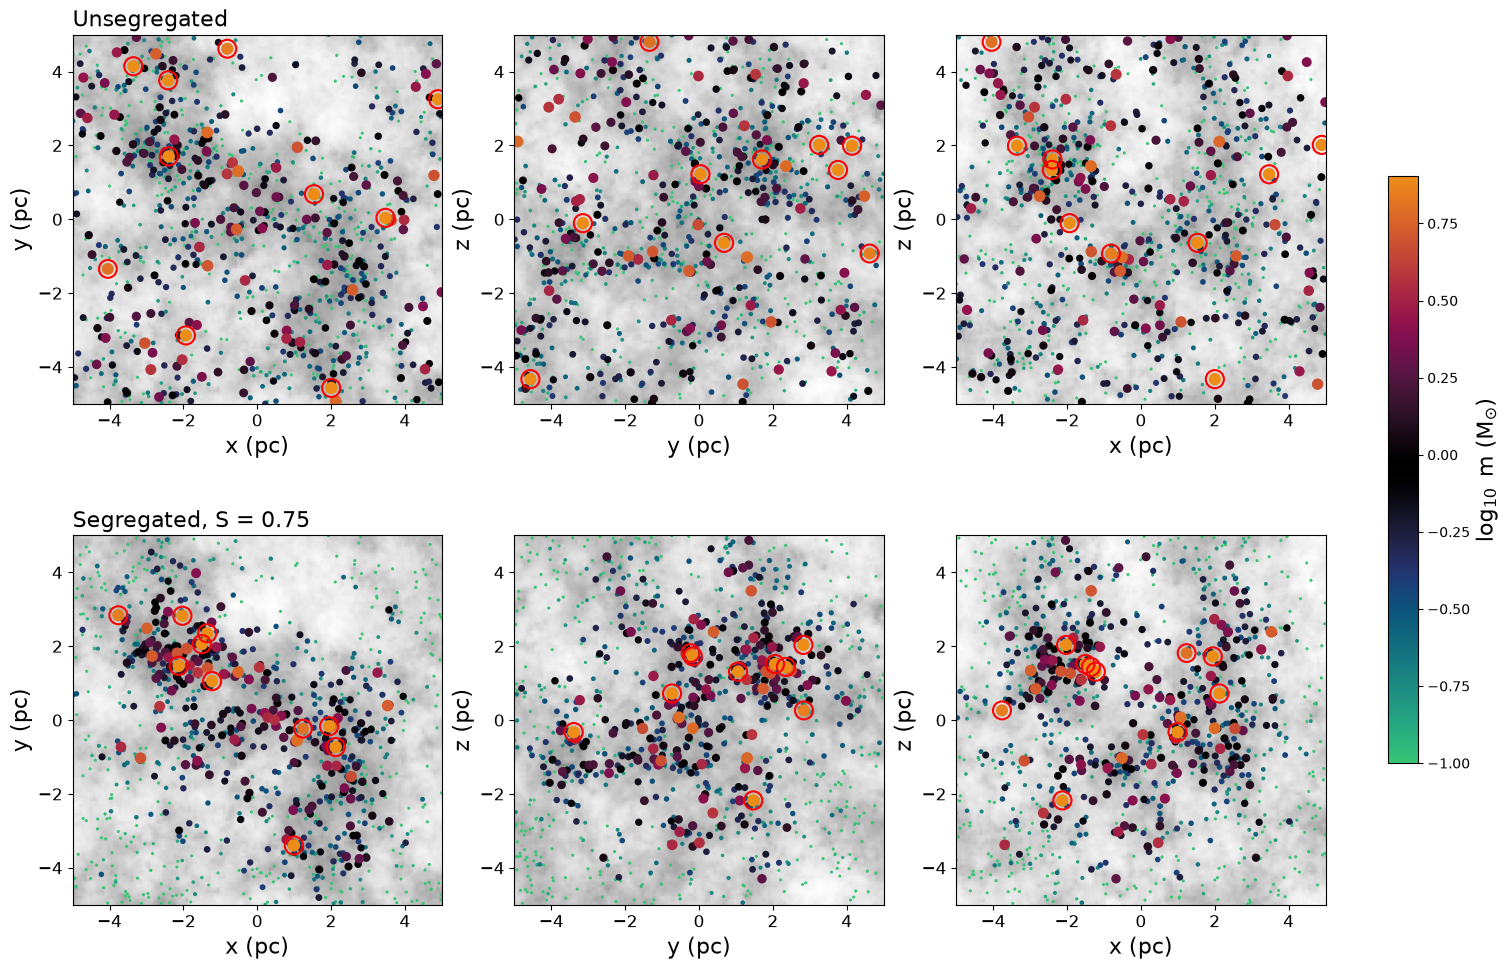

In [8]:
#Unsegregated (top) vs segregated (bottom); the 10 most massive are circled in red
top10 = np.argsort(-m_arr)[:10]
clusters = [((x, y, z), "Unsegregated"), ((xs, ys, zs), f"Segregated, S = {S}")]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for row, ((cx, cy, cz), title) in zip(axes, clusters):
    planes = [(cx, cy, "x", "y", 2), (cy, cz, "y", "z", 0), (cx, cz, "x", "z", 1)]
    for ax, (a, b, la, lb, si) in zip(row, planes):
        sc = plotStars(ax, a, b)
        ax.scatter(a[top10], b[top10], s=starSize[top10] + 90, facecolors='none', edgecolors='r', lw=1.5)

        pdfProj = np.sum(spatProb, axis=si)
        ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.5, origin='lower', norm=colors.LogNorm())
        
        ax.set_xlim(-L/2, L/2)
        ax.set_ylim(-L/2, L/2)
        ax.set_aspect('equal')
        ax.set_xlabel(f"{la} (pc)", fontsize=16)
        ax.set_ylabel(f"{lb} (pc)", fontsize=16)
        ax.tick_params(which='both', axis='both', labelsize=12)
    row[0].set_title(title, fontsize=16, loc='left')
cb = fig.colorbar(sc, ax=axes, shrink=0.6)
cb.set_label(r"$\log_{10}$ m (M$_{\odot}$)", fontsize=16)
plt.show()

In [9]:
#Mass segregation ratio (Allison et al. 2009); Lambda_MSR ~ 1 means no segregation
lam, lamErr = spatialObj.lambdaMSR((x, y, z), m_arr, nmst=10)
lamS, lamErrS = spatialObj.lambdaMSR((xs, ys, zs), m_arr, nmst=10)
print(f"Unsegregated:  Lambda_MSR = {lam:.2f} +/- {lamErr:.2f}")
print(f"S = {S}:      Lambda_MSR = {lamS:.2f} +/- {lamErrS:.2f}")

Unsegregated:  Lambda_MSR = 0.89 +/- 0.13
S = 0.75:      Lambda_MSR = 1.85 +/- 0.25


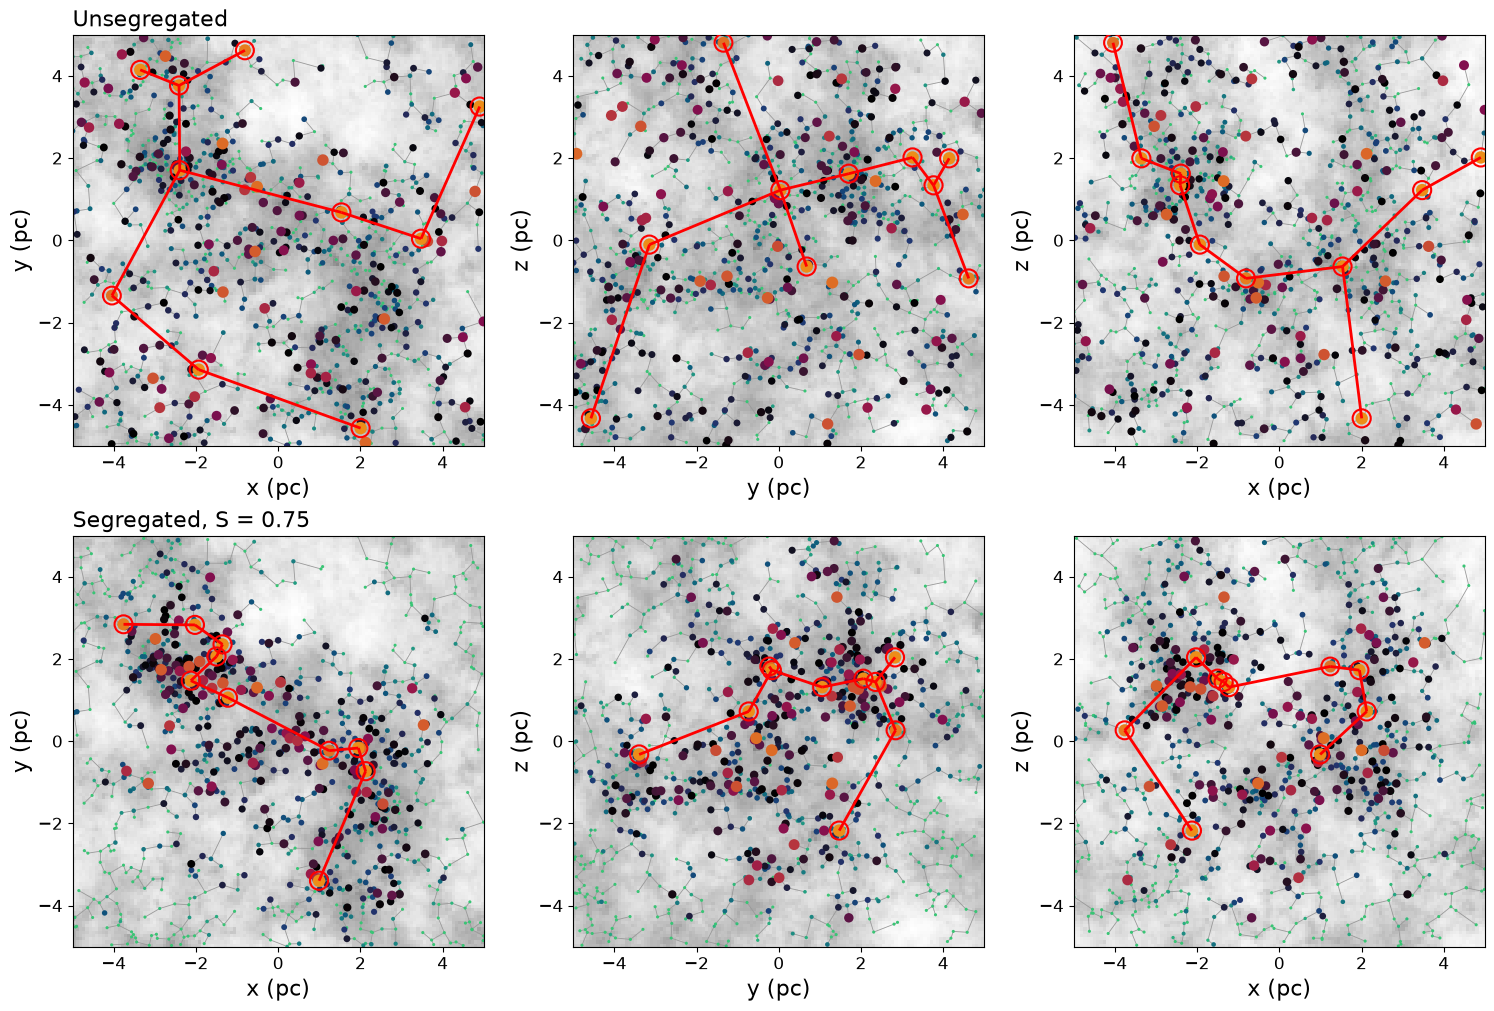

In [10]:
#Projected minimum spanning trees: full cluster (grey) and the 10 most massive (red)
from matplotlib.collections import LineCollection

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for row, ((cx, cy, cz), title) in zip(axes, clusters):
    planes = [(cx, cy, "x", "y", 2), (cy, cz, "y", "z", 0), (cx, cz, "x", "z", 1)]
    for ax, (a, b, la, lb, si) in zip(row, planes):
        #mst returns (edges, lengths, segments)
        _, _, segAll = spatialObj.mst((a, b))
        _, _, segTop = spatialObj.mst((a[top10], b[top10]))
        ax.add_collection(LineCollection(segAll, colors='0.6', lw=0.6, zorder=1))
        plotStars(ax, a, b, zorder=2)
        ax.add_collection(LineCollection(segTop, colors='r', lw=2, zorder=3))
        ax.scatter(a[top10], b[top10], s=starSize[top10] + 90, facecolors='none', edgecolors='r', lw=1.5, zorder=4)

        pdfProj = np.sum(spatProb, axis=si)
        ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.5, origin='lower', norm=colors.LogNorm())
        
        ax.set_xlim(-L/2, L/2)
        ax.set_ylim(-L/2, L/2)
        ax.set_aspect('equal')
        ax.set_xlabel(f"{la} (pc)", fontsize=16)
        ax.set_ylabel(f"{lb} (pc)", fontsize=16)
        ax.tick_params(which='both', axis='both', labelsize=12)
    row[0].set_title(title, fontsize=16, loc='left')
plt.show()